# Анализ системы метрик приложения
- **Автор:** Алиса Гизова
- **Дата:** 25.10.2025

### Контекст:
Запуск нового тематического раздела и новой маркетинговой стратегии в подписочном сервисе привёл к парадоксу: интерес к продукту вырос, но рост выручки остановился. Бизнес-модель требует окупаемости затрат на привлечение за первые 28 дней.

### Цель:
Выяснить, почему выручка перестала расти, и дать рекомендации по корректировке стратегии.

### Ключевые вопросы:
- Почему выручка стагнирует при росте интереса?
- Окупается ли привлечение в течение 28 дней?
- Какие каналы привлечения прибыльны, а какие — нет?

### Задачи:
- Проанализировать динамику юнит-экономики (CAC, LTV) за 28 дней.
- Оценить влияние нового контента на поведение и платежи пользователей.
- Определить окупаемость каждого канала привлечения.
- Подготовить рекомендации для маркетинга.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.

## Загрузка и предобработка данных

In [4]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

In [6]:
# Выводим первые строки датафрейма visits_df на экран
visits_df.head()

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


In [7]:
# Выводим информацию о датафрейме
visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  datetime64[ns]
 5   session_end    161865 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 7.4+ MB


In [8]:
# Выводим первые строки датафрейма orders_df на экран
orders_df.head()

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99


In [9]:
# Выводим информацию о датафрейме
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   33893 non-null  int64         
 1   event_dt  33893 non-null  datetime64[ns]
 2   revenue   33893 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 794.5 KB


In [10]:
# Выводим первые строки датафрейма costs_df на экран
costs_df.head()

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760


In [11]:
# Выводим информацию о датафрейме
costs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       976 non-null    datetime64[ns]
 1   channel  976 non-null    object        
 2   costs    976 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.0+ KB


---

Датасет `ppro_visits.csv` содержит 6 столбцов и 161865 строк, в которых представлена информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов соответствуют их содержимому и представлены в едином стиле.
- Представленные данные содержат числовые (`int64`) и строковые значения (`object`).
- Датасет не содержит пропусков.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Датасет `ppro_orders.csv` содержит 3 столбца и 33893 строки, в которых представлена информация о покупках.

По аналогии с предыдущим датасетом можно отметить, что:
- Названия столбцов соответствуют их содержимому и представлены в едином стиле.
- Представленные данные содержат числовые (`int64` и `float64`) и строковые значения (`object`).
- Датасет не содержит пропусков.
- Значения в столбцах соответствуют описанию.

Датасет `ppro_costs.csv` содержит 3 столбца и 976 строк, в которых представлена информация о затратах на маркетинг.

Можно отметить, что:
- Названия столбцов соответствуют их содержимому и представлены в едином стиле.
- Представленные данные содержат числовые (`float64`) и строковые значения (`object`).
- Датасет не содержит пропусков.
- Значения в столбцах соответствуют описанию.

После анализа типов данных видно, что присутствуют столбцы, типы данных которых представлены некорректно. Для оптимизации работы с данными можно преобразовать данные в столбцах в подходящий для каждого столбца тип данных. Датасеты не содержат пропусков. Названия столбцов отражают содержимое данных и представлены в стиле `snake case`.

Проверим данные на наличие дубликатов.

In [14]:
# Проверяем полные дубликаты в датафрейме
visits_df.duplicated().sum()

0

In [15]:
# Проверяем полные дубликаты в датафрейме
orders_df.duplicated().sum()

0

In [16]:
# Проверяем полные дубликаты в датафрейме
costs_df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк.

## Подготовка данных к когортному анализу

In [19]:
# VISITS
visits_df = visits_df.dropna(subset=["user_id", "region", "device", "channel", "session_start", "session_end"])
visits_df["session_duration_sec"] = (visits_df["session_end"] - visits_df["session_start"]).dt.total_seconds()
visits_df = visits_df[(visits_df["session_end"] >= visits_df["session_start"]) & (visits_df["session_duration_sec"] > 0)]
visits_df = visits_df.drop_duplicates()
p99 = visits_df["session_duration_sec"].quantile(0.99)
visits_df["session_duration_sec_capped"] = np.minimum(visits_df["session_duration_sec"], p99)

# ORDERS
orders_df = orders_df.dropna(subset=["user_id", "event_dt", "revenue"])
orders_df = orders_df[orders_df["revenue"] > 0]
orders_df = orders_df.drop_duplicates(subset=["user_id", "event_dt", "revenue"])

# COSTS
costs_df = costs_df.dropna(subset=["dt", "channel", "costs"])
costs_df = costs_df[costs_df["costs"] > 0]
costs_df = costs_df.groupby(["dt", "channel"], as_index=False)["costs"].sum()

# Каналы
channels_visits = set(visits_df["channel"].unique())
channels_costs = set(costs_df["channel"].unique())
common_channels = channels_visits & channels_costs

print("=== предобработка ===")
print("visits:", visits_df.shape)
print("orders:", orders_df.shape)
print("costs:", costs_df.shape)
print("Общее количество пересекающихся каналов:", len(common_channels))

=== предобработка ===
visits: (159179, 8)
orders: (33893, 3)
costs: (976, 3)
Общее количество пересекающихся каналов: 4


In [20]:
# Приводим даты к одинаковому формату
visits_df['session_date'] = visits_df['session_start'].dt.normalize()


# Сортируем визиты по времени сессии
visits_df = visits_df.sort_values(by="session_start")

# Для каждого пользователя — первая дата и первый канал
user_profiles = visits_df.groupby("user_id").agg(
    first_dt=("session_start", "min"),
    first_channel=("channel", "first")
).reset_index()

# Добавим столбец даты для объединения с costs
user_profiles["acq_date"] = user_profiles["first_dt"].dt.normalize()

# Считаем число пользователей по дате и каналу
user_counts = user_profiles.groupby(["acq_date", "first_channel"]).agg(
    user_count=("user_id", "count")
).reset_index()

# Добавим маркетинговые затраты
merged_costs = costs_df.rename(columns={"dt": "acq_date", "channel": "first_channel"})
merged = user_counts.merge(merged_costs, on=["acq_date", "first_channel"], how="left")

# Расчёт CAC
merged["CAC"] = merged["costs"] / merged["user_count"]

# Присоединяем CAC обратно к пользователям
profiles = user_profiles.merge(
    merged[["acq_date", "first_channel", "CAC"]],
    on=["acq_date", "first_channel"],
    how="left"
)

# Финальный вид таблицы
profiles = profiles[["user_id", "first_dt", "first_channel", "CAC"]]

display(profiles.head())

,user_id,first_dt,first_channel,CAC
0,26034876,2024-05-29 10:24:00,FaceBoom,0.974915
1,69890364,2024-06-28 05:48:00,RocketSuperAds,0.604917
2,75610104,2024-06-09 06:48:00,FaceBoom,1.208121
3,76692397,2024-10-21 01:51:00,FaceBoom,1.187214
4,80224421,2024-06-21 11:47:00,FaceBoom,1.228964


In [21]:
# Добавляем информацию о первом привлечении к данным о посещениях
visits_df = pd.merge(
    visits_df,
    profiles[['user_id', 'first_dt', 'first_channel', 'CAC']],
    on='user_id',
    how='left'
)

# Добавляем информацию о первом привлечении к данным о покупках
orders_df = pd.merge(
    orders_df,
    profiles[['user_id', 'first_dt', 'first_channel', 'CAC']],
    on='user_id',
    how='left'
)

visits_df['session_date'] = visits_df['session_start'].dt.normalize()
visits_df['first_dt'] = visits_df['first_dt'].dt.normalize()

orders_df = orders_df.dropna()

In [22]:
# Рассчитываем дневной лайфтайм для каждого события

# Для посещений
visits_df['lifetime'] = (
    visits_df['session_start'] - visits_df['first_dt']
).dt.days.astype('int')

# Для покупок
orders_df['lifetime'] = (
    orders_df['event_dt'] - orders_df['first_dt']
).dt.days.astype('int')

Данные подготовлены к когортному анализу:
- Для каждого пользователя определена дата первой сессии, канал привлечения и стоимость привлечения пользователя.
- Рассчитан дневной лайфтайм для каждого события и покупки.
- В резульатте получилось три датафрейма:
    - visits_df;
    - orders_df;
    - profiles.

## Анализ месячной динамики основных метрик продукта

In [25]:
# Создаем копию данных для безопасности
daily_analysis = visits_df.copy()

# Создаем отдельную колонку с датой
daily_analysis['date'] = daily_analysis['session_start'].dt.normalize()

# Группируем по дате и считаем метрики
daily_metrics = daily_analysis.groupby('date').agg(
    DAU=('user_id', 'nunique')
).reset_index()

display(daily_metrics.head())

,date,DAU
0,2024-04-01,349
1,2024-04-02,403
2,2024-04-03,476
3,2024-04-04,462
4,2024-04-05,524


In [26]:
# Рассчитываем ежемесячные метрики
daily_metrics['year_month'] = daily_metrics['date'].apply(lambda x: x.strftime('%Y-%m'))

monthly_activity = daily_metrics.groupby('year_month').agg({
    'DAU': 'mean'
}).reset_index()

# Рассчитываем MAU (уникальные пользователи в месяц)
monthly_unique = visits_df.groupby(
    visits_df['session_start'].dt.to_period('M')
)['user_id'].nunique().reset_index()

monthly_unique['year_month'] = monthly_unique['session_start'].astype(str)
monthly_activity = pd.merge(
    monthly_activity,
    monthly_unique[['year_month', 'user_id']],
    on='year_month',
    how='left'
)

monthly_activity = monthly_activity.rename(columns={
    'user_id': 'MAU',
    'DAU': 'avg_DAU'
})

# Рассчитываем Stickiness (DAU/MAU)
monthly_activity['stickiness'] = monthly_activity['avg_DAU'] / monthly_activity['MAU']

display("Ежемесячные метрики активности:")
display(monthly_activity.head())

'Ежемесячные метрики активности:'

,year_month,avg_DAU,MAU,stickiness
0,2024-04,480.133333,8979,0.053473
1,2024-05,567.870968,10738,0.052884
2,2024-06,571.100000,10160,0.056211
3,2024-07,605.129032,10765,0.056213
4,2024-08,669.612903,11855,0.056484


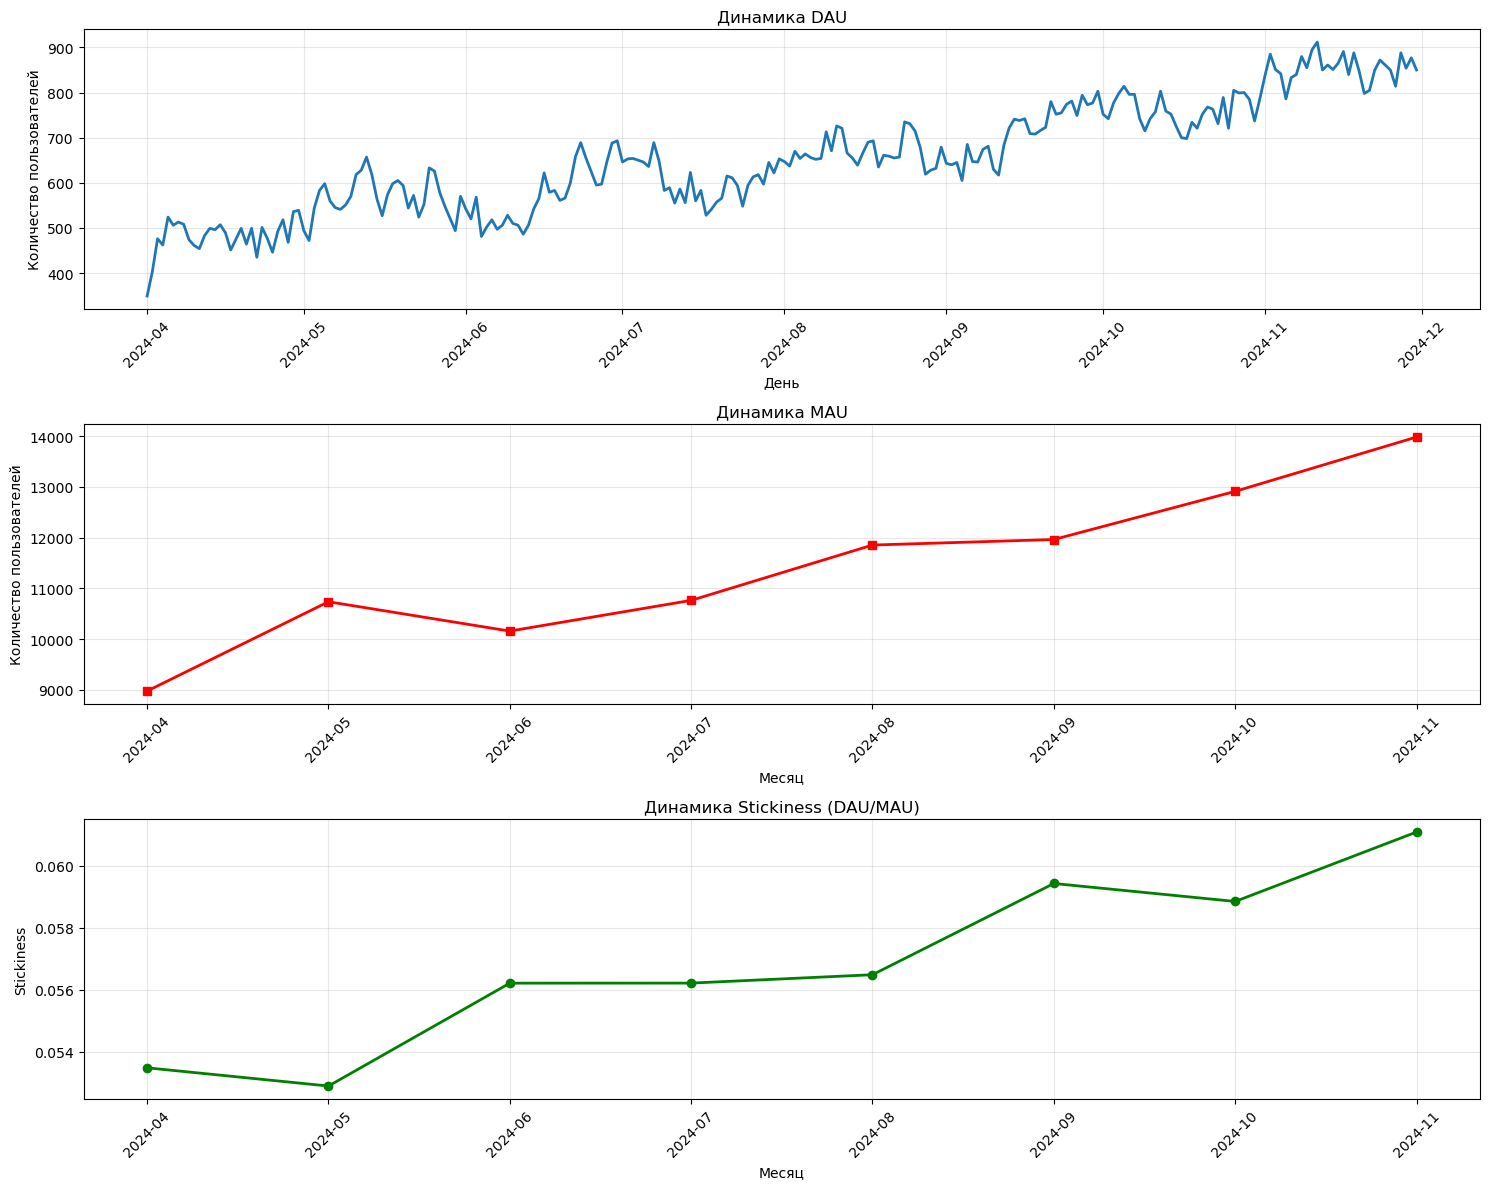

In [27]:
# Визуализация метрик активности
plt.figure(figsize=(15, 12))

# График 1: DAU
plt.subplot(3, 1, 1)
plt.plot(daily_metrics['date'], daily_metrics['DAU'], 
          linewidth=2)
plt.title('Динамика DAU')
plt.xlabel('День')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# График 2: MAU
plt.subplot(3, 1, 2)
plt.plot(monthly_activity['year_month'], monthly_activity['MAU'], 
         marker='s', linewidth=2,  color='red')
plt.title('Динамика MAU')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# График 3: Stickiness
plt.subplot(3, 1, 3)
plt.plot(monthly_activity['year_month'], monthly_activity['stickiness'], 
         marker='o', linewidth=2, color='green')
plt.title('Динамика Stickiness (DAU/MAU)')
plt.xlabel('Месяц')
plt.ylabel('Stickiness')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,first_month,total_users,avg_cac
0,2024-04-01,8979,0.742071
1,2024-05-01,9705,0.755052
2,2024-06-01,8659,0.980727
3,2024-07-01,8668,1.063345
4,2024-08-01,9437,1.165520


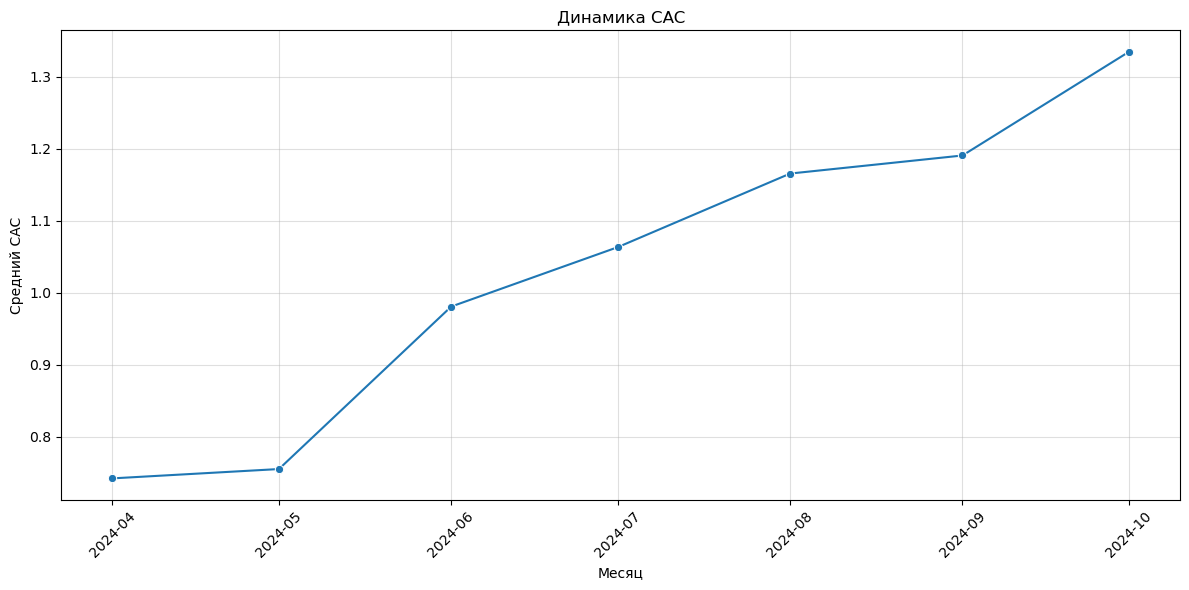

In [28]:
# Группируем данные по месяцу, считаем средний САС
cac_df = profiles.copy()

# Выделяем первый месяц привлечения
cac_df['first_month'] = cac_df['first_dt'].dt.to_period('M').dt.to_timestamp()

# Удаляем данные за последний доступный месяц
last_month = cac_df['first_month'].max()
cac_df = cac_df[cac_df['first_month'] != last_month]

# Группируем данные по месяцу, считаем средний САС
cac = cac_df.groupby(['first_month']).agg(
total_users = ('user_id','nunique'),
avg_cac = ('CAC','mean'),
).reset_index()

display(cac.head())

# Конвертируем first_month в timestamp для корректной работы с осью времени
cac['first_month'] = pd.to_datetime(cac['first_month'])

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график
sns.lineplot(
    data=cac,
    x='first_month',
    y='avg_cac',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Месяц')
plt.ylabel('Средний CAC')

# Добавляем заголовок
plt.title('Динамика CAC')

plt.tight_layout()
plt.show()

Метрики по месяцам привлечения:
  first_month  cohort_size       CAC       LTV        ROI
0     2024-04         8979  0.742071  0.840546  13.270310
1     2024-05         9705  0.755052  0.852232  12.870681
2     2024-06         8659  0.980727  0.874632 -10.817996
3     2024-07         8668  1.063345  1.174249  10.429676
4     2024-08         9437  1.165520  1.119472  -3.950842
5     2024-09         9103  1.190598  1.125666  -5.453718
6     2024-10         9436  1.334824  1.236970  -7.330874


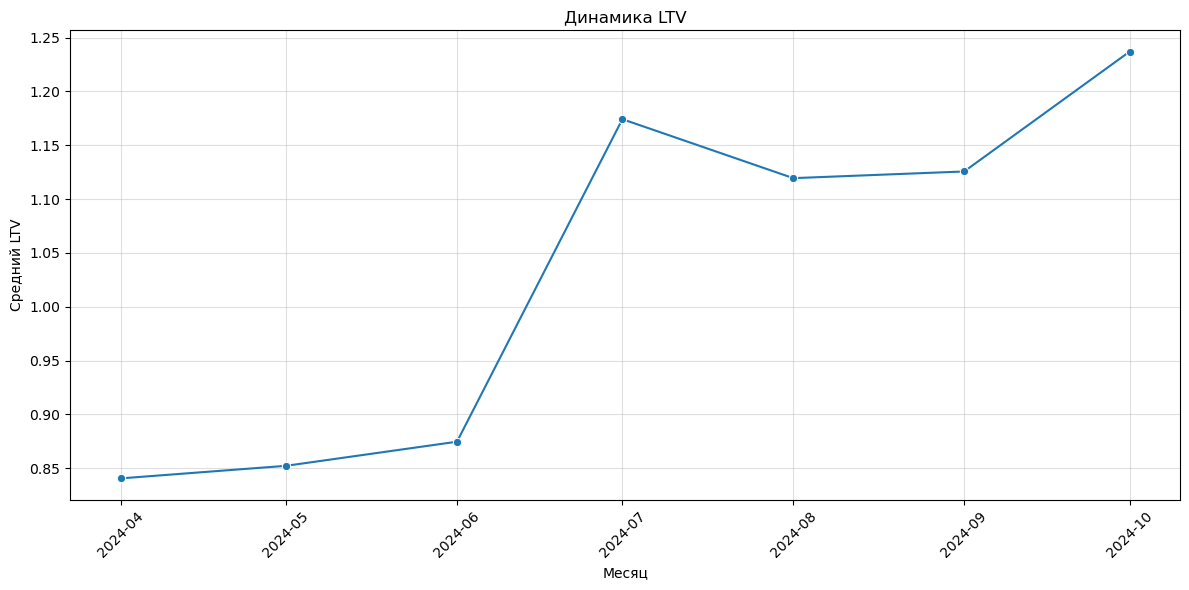

In [29]:
# Создаем когорты по месяцам привлечения
profiles['first_month'] = profiles['first_dt'].dt.to_period('M').astype(str)

# Фильтруем данные о покупках за первые 28 дней
orders_28d = orders_df[orders_df['lifetime'] <= 28].copy()

# Рассчитываем LTV за 28 дней для каждого пользователя
ltv = orders_28d.groupby('user_id')['revenue'].sum().reset_index()
ltv = ltv.rename(columns={'revenue': 'LTV'})

# Добавляем LTV к профилям
ltv = pd.merge(
    profiles,
    ltv[['user_id', 'LTV']],
    on='user_id',
    how='left'
)

ltv['LTV'] = ltv['LTV'].fillna(0)

# Удаляем данные за последний доступный месяц
last_month = ltv['first_month'].max()
ltv = ltv[ltv['first_month'] != last_month]

# Рассчитываем метрики по когортам (месяцам привлечения)
ltv = ltv.groupby('first_month').agg({
    'user_id': 'count',
    'CAC': 'mean',
    'LTV': 'mean'
}).reset_index()

ltv = ltv.rename(columns={
    'user_id': 'cohort_size',
})

# Рассчитываем ROI за 28 дней
ltv['ROI'] = (ltv['LTV'] - ltv['CAC']) / ltv['CAC'] * 100
ltv['ROI'] = ltv['ROI'].replace([np.inf, -np.inf], 0)

print("Метрики по месяцам привлечения:")
print(ltv.round(6))

# display(ltv.head())

# Конвертируем first_month в timestamp для корректной работы с осью времени
ltv['first_month'] = pd.to_datetime(ltv['first_month'])

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график
sns.lineplot(
    data=ltv,
    x='first_month',
    y='LTV',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Месяц')
plt.ylabel('Средний LTV')

# Добавляем заголовок
plt.title('Динамика LTV')

plt.tight_layout()
plt.show()

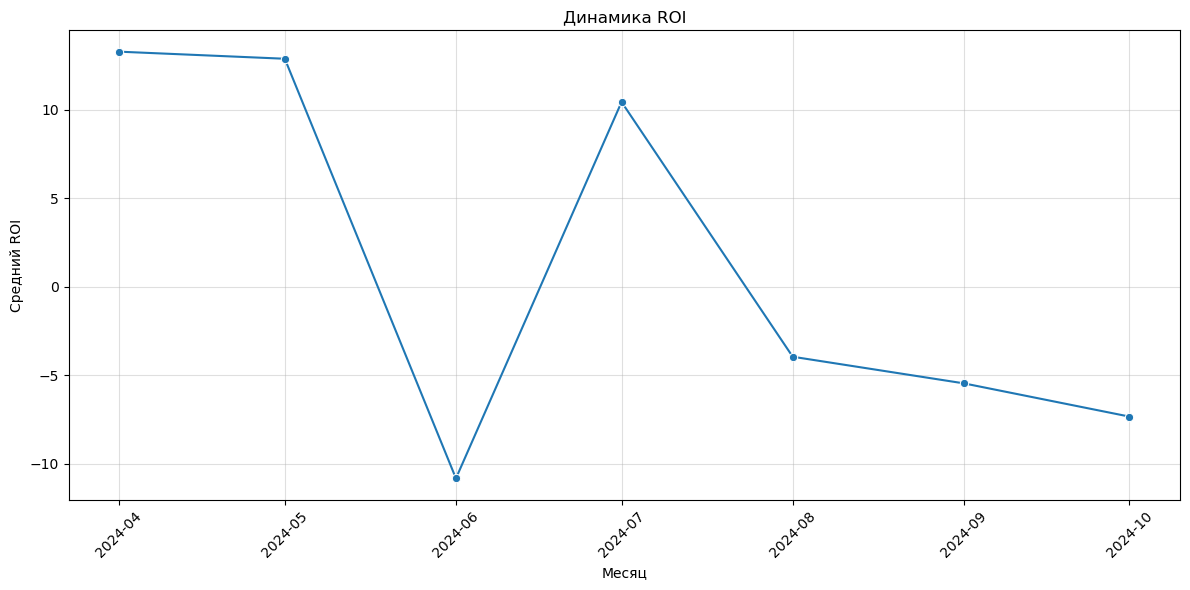

,first_month,cohort_size,CAC,LTV,ROI
0,2024-04-01,8979,0.742071,0.840546,13.270310
1,2024-05-01,9705,0.755052,0.852232,12.870681
2,2024-06-01,8659,0.980727,0.874632,-10.817996
3,2024-07-01,8668,1.063345,1.174249,10.429676
4,2024-08-01,9437,1.165520,1.119472,-3.950842


In [30]:
# Конвертируем first_month в timestamp для корректной работы с осью времени
ltv['first_month'] = pd.to_datetime(ltv['first_month'])

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график
sns.lineplot(
    data=ltv,
    x='first_month',
    y='ROI',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Месяц')
plt.ylabel('Средний ROI')

# Добавляем заголовок
plt.title('Динамика ROI')

plt.tight_layout()
plt.show()

display(ltv.head())

**Промежуточный вывод:** 

С началом лета (июнь 2024) — после запуска нового контента — наблюдается устойчивый рост ключевых метрик продукта:
- DAU и MAU продолжают расти, особенно заметно с июля;
- Stickiness (вовлечённость) увеличилась с 0.054 до 0.062 — пользователи стали активнее;
- LTV новых когорт (начиная с июня) выросла;
- ROI остается примерно на том же уровне.

Средний CAC (стоимость привлечения) вырос в июне–августе, но затем стабилизировался — вероятно, из-за масштабирования или изменения каналов привлечения.

## Анализ метрик в разрезе источника привлечения

In [33]:
# Общее число привлеченных пользователей
channel_users = profiles.groupby('first_channel').agg({
    'user_id': 'count'
}).round(2)

channel_users = channel_users.rename(columns={
    'user_id': 'total_users'
})

channel_users = channel_users.sort_values('total_users', ascending=False)

display(channel_users)

,total_users
first_channel,
FaceBoom,28036
TipTop,18029
RocketSuperAds,14138
MediaTornado,14009


In [34]:
# Готовим данные для анализа динамики
daily_channel_growth = profiles.groupby([
    profiles['first_dt'].dt.date,
    'first_channel'
]).size().reset_index(name='new_users')

daily_channel_growth = daily_channel_growth.rename(columns={'first_dt': 'date'})

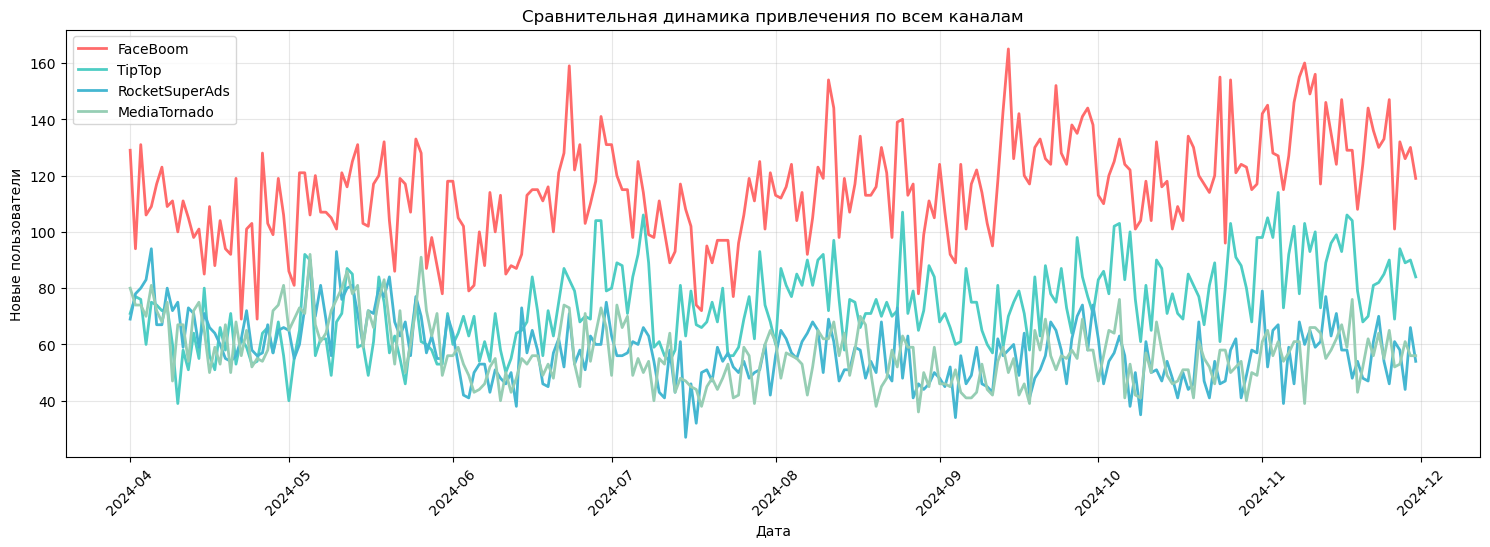

In [35]:
# Сравнительная динамика
plt.figure(figsize=(15, 10))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

plt.subplot(2, 1, 2)
for i, channel in enumerate(channel_users.index):
    channel_data = daily_channel_growth[daily_channel_growth['first_channel'] == channel]
    plt.plot(channel_data['date'], channel_data['new_users'], linewidth=2, color=colors[i], label=channel)

plt.title('Сравнительная динамика привлечения по всем каналам')
plt.xlabel('Дата')
plt.ylabel('Новые пользователи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

График показывает динамику привлечения новых пользователей по четырём каналам.

- FaceBoom — лидер по объёму привлечения, с высокой волатильностью и пиковыми значениями до 160+ пользователей.
- TipTop — стабильно на втором месте, с умеренной волатильностью и ростом к концу периода.
- RocketSuperAds и MediaTornado — значительно слабее, с низкими и нестабильными показателями, часто пересекаются.

Вывод: основной трафик приходит через FaceBoom, остальные каналы — вспомогательные или менее эффективные.

In [37]:
# Создаем копию для безопасности
visits_with_channel = visits_df.copy()

# Создаем отдельную колонку с датой для безопасности
visits_with_channel['date'] = visits_with_channel['session_start'].dt.normalize()

# Создаем ежедневные метрики активности по каналам
daily_channel_activity = visits_with_channel.groupby([
    'date',
    'first_channel'
]).agg(
    DAU=('user_id', 'nunique')
).reset_index()

display(daily_channel_activity.head())

# Рассчитываем ежемесячные метрики по каналам
daily_channel_activity['year_month'] = daily_channel_activity['date'].apply(lambda x: x.strftime('%Y-%m'))

monthly_channel_activity = daily_channel_activity.groupby(['year_month', 'first_channel']).agg({
    'DAU': 'mean'
}).reset_index()

# Рассчитываем MAU по каналам
visits_with_channel['year_month'] = visits_with_channel['session_start'].dt.to_period('M').astype(str)
monthly_channel_unique = visits_with_channel.groupby([
    'year_month',
    'first_channel'
])['user_id'].nunique().reset_index()

monthly_channel_unique = monthly_channel_unique.rename(columns={'user_id': 'MAU'})

# Объединяем метрики
monthly_channel_activity = pd.merge(
    monthly_channel_activity,
    monthly_channel_unique[['year_month', 'first_channel', 'MAU']],
    on=['year_month', 'first_channel'],
    how='left'
)

monthly_channel_activity = monthly_channel_activity.rename(columns={
    'DAU': 'avg_DAU',
    'sessions': 'avg_sessions'
})

# Рассчитываем Stickiness по каналам
monthly_channel_activity['stickiness'] = monthly_channel_activity['avg_DAU'] / monthly_channel_activity['MAU']

,date,first_channel,DAU
0,2024-04-01,FaceBoom,129
1,2024-04-01,MediaTornado,80
2,2024-04-01,RocketSuperAds,69
3,2024-04-01,TipTop,71
4,2024-04-02,FaceBoom,113


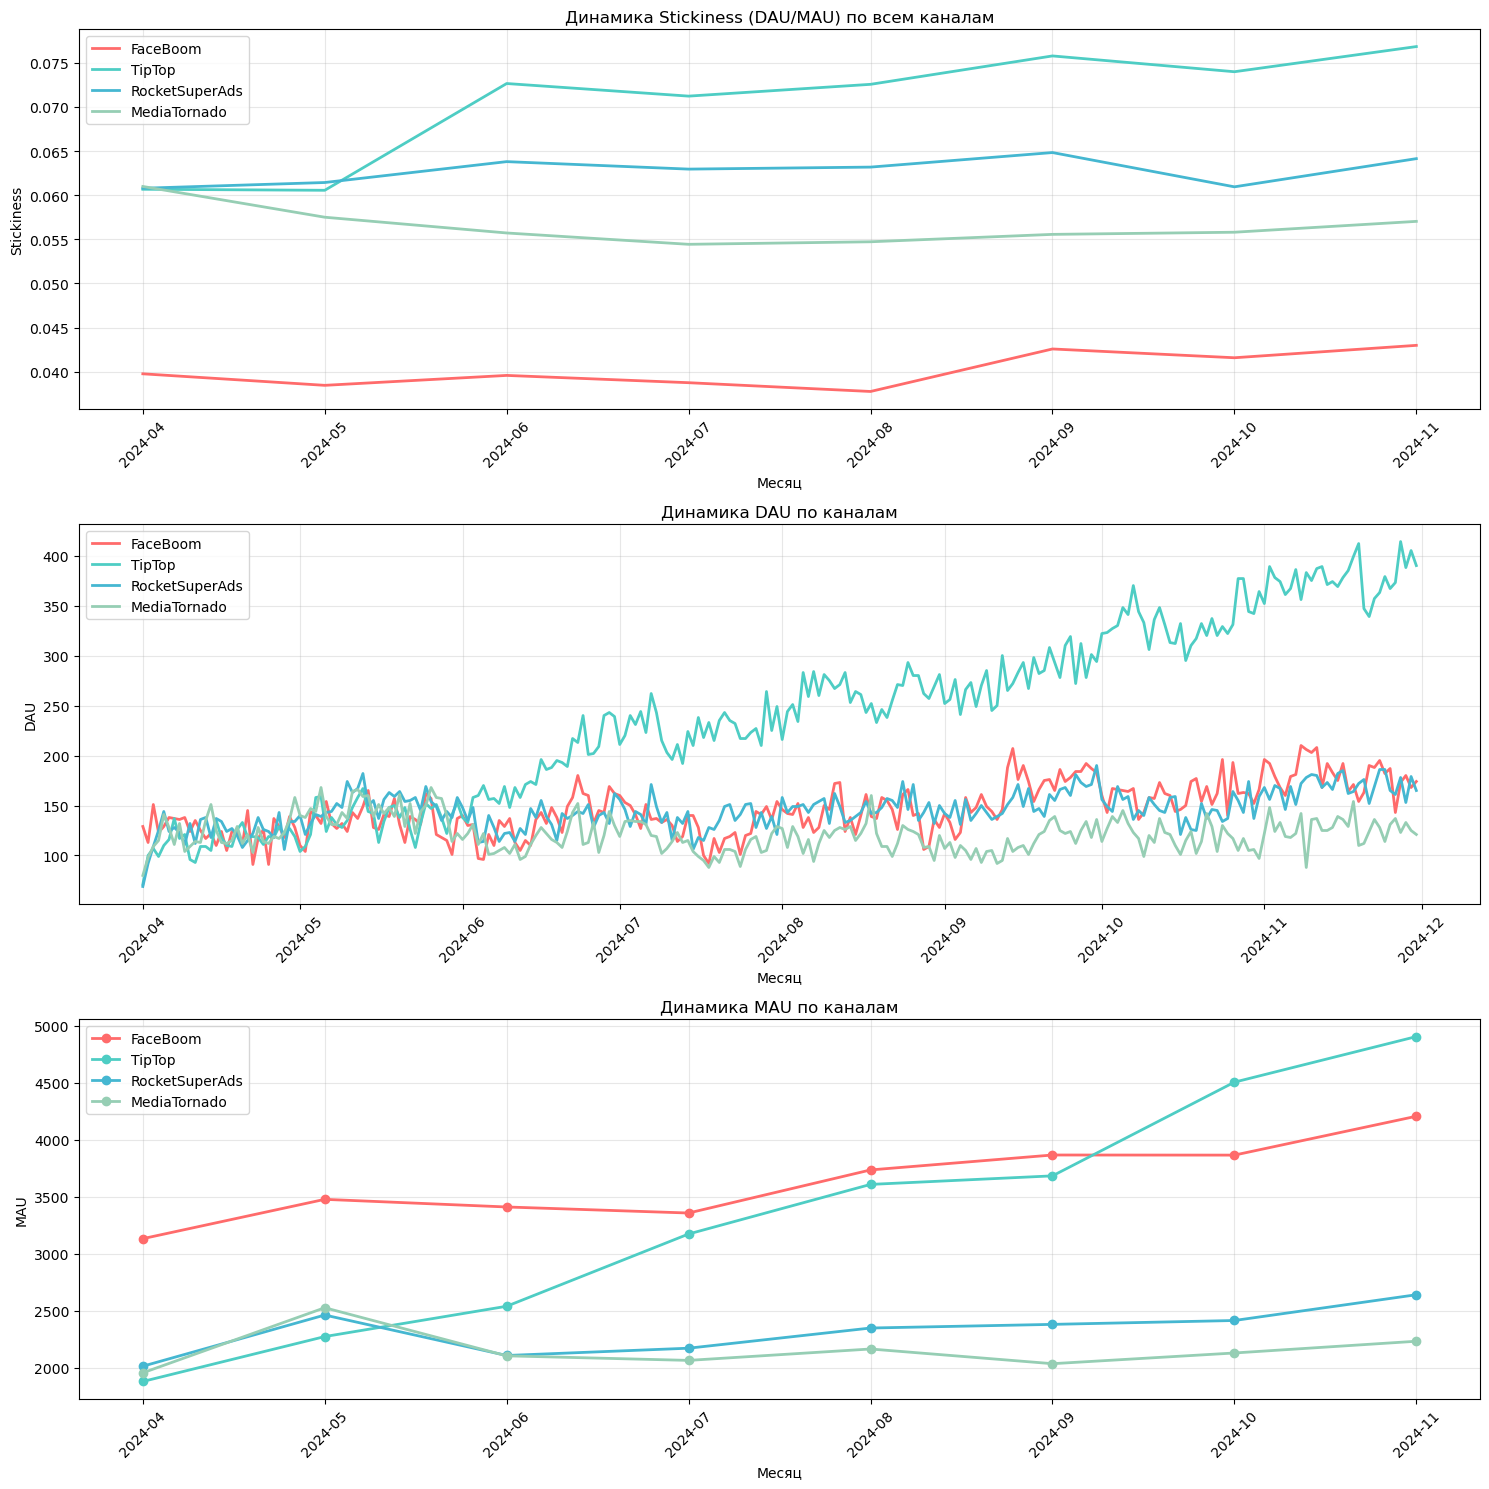

In [38]:
# Визуализация метрик активности по каналам
plt.figure(figsize=(15, 15))

# График 1: Stickiness по каналам
plt.subplot(3, 1, 1)
for i, channel in enumerate(channel_users.index):
    channel_data = monthly_channel_activity[monthly_channel_activity['first_channel'] == channel]
    plt.plot(channel_data['year_month'], channel_data['stickiness'], 
             linewidth=2, color=colors[i], label=channel)

plt.title('Динамика Stickiness (DAU/MAU) по всем каналам')
plt.xlabel('Месяц')
plt.ylabel('Stickiness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# График 2: DAU по каналам
plt.subplot(3, 1, 2)
for i, channel in enumerate(channel_users.index):
    channel_data = daily_channel_activity[daily_channel_activity['first_channel'] == channel]
    plt.plot(channel_data['date'], channel_data['DAU'], 
             linewidth=2, color=colors[i], label=channel)

plt.title('Динамика DAU по каналам')
plt.xlabel('Месяц')
plt.ylabel('DAU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# График 3: MAU по каналам
plt.subplot(3, 1, 3)
for i, channel in enumerate(channel_users.index):
    channel_data = monthly_channel_activity[monthly_channel_activity['first_channel'] == channel]
    plt.plot(channel_data['year_month'], channel_data['MAU'], 
             marker='o', linewidth=2, color=colors[i], label=channel)

plt.title('Динамика MAU по каналам')
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Stickiness (DAU/MAU) — TipTop лидирует с ростом до 0.075, остальные каналы стабильны или слабо растут. Высокая вовлечённость у TipTop.
- DAU — TipTop демонстрирует уверенный рост (до 400+), FaceBoom и RocketSuperAds — на уровне 150–200, MediaTornado — ниже всех (~100).
- MAU — TipTop растёт рекордными темпами (до 500+), FaceBoom — медленно растёт (~ 420), остальные — почти стагнация (~ 250).

Вывод: TipTop — самый эффективный канал по удержанию и масштабу аудитории. FaceBoom — стабилен, но не растёт. Остальные каналы — низкая эффективность.

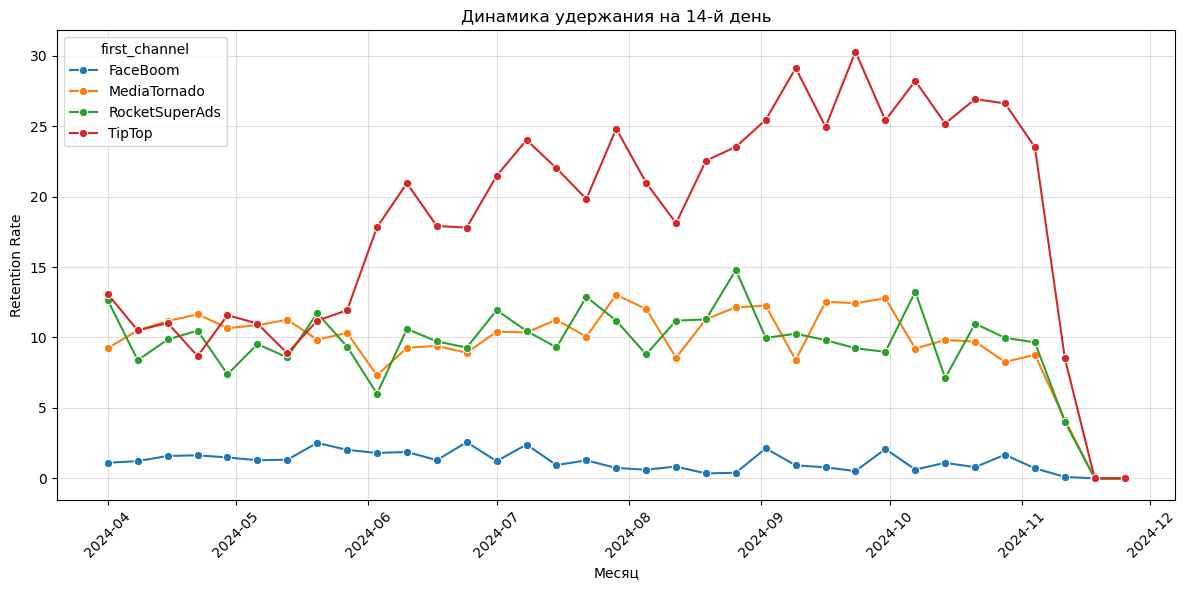

In [40]:
# считаем размер когорт

profiles['first_week'] = profiles['first_dt'].dt.to_period('W').dt.to_timestamp()

cohort_sizes = profiles.groupby(['first_week', 'first_channel'])['user_id'].nunique().reset_index()
cohort_sizes.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# считаем количество активных пользоателей в дни 14-28

visits_df['first_week'] = visits_df['first_dt'].dt.to_period('W').dt.to_timestamp()

retained_users = visits_df[
    (visits_df['lifetime'] >= 14) & 
    (visits_df['lifetime'] <= 28)       # фильтруем активность в 14-28 дни
].groupby(['first_week', 'first_channel'])['user_id'].nunique().reset_index()
retained_users.rename(columns={'user_id': 'retained_count'}, inplace=True)

# объединяем данные

retention_rate = cohort_sizes.merge(retained_users, on=['first_week', 'first_channel'], how='left')
retention_rate['retention_rate'] = retention_rate['retained_count'] / retention_rate['cohort_size'] * 100
retention_rate['retention_rate'] = retention_rate['retention_rate'].fillna(0)


# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график с разделением по каналам
sns.lineplot(
    data=retention_rate,
    x='first_week',
    y='retention_rate',
    hue='first_channel',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Месяц')
plt.ylabel('Retention Rate')

# Добавляем заголовок
plt.title('Динамика удержания на 14-й день')

plt.tight_layout()
plt.show()

График показывает удержание на 14-й день по каналам.

- TipTop — лидер по удержанию (до 30%), но резко падает в ноябре–декабре до нуля — возможен сбой или остановка канала.
- RocketSuperAds и MediaTornado — средний уровень удержания (~10–15%), с колебаниями.
- FaceBoom — худший результат, почти не превышает 2–3%.

Вывод: TipTop — лучший канал по удержанию, но его эффективность резко упала в конце периода. FaceBoom — слабый по удержанию, несмотря на высокий трафик.

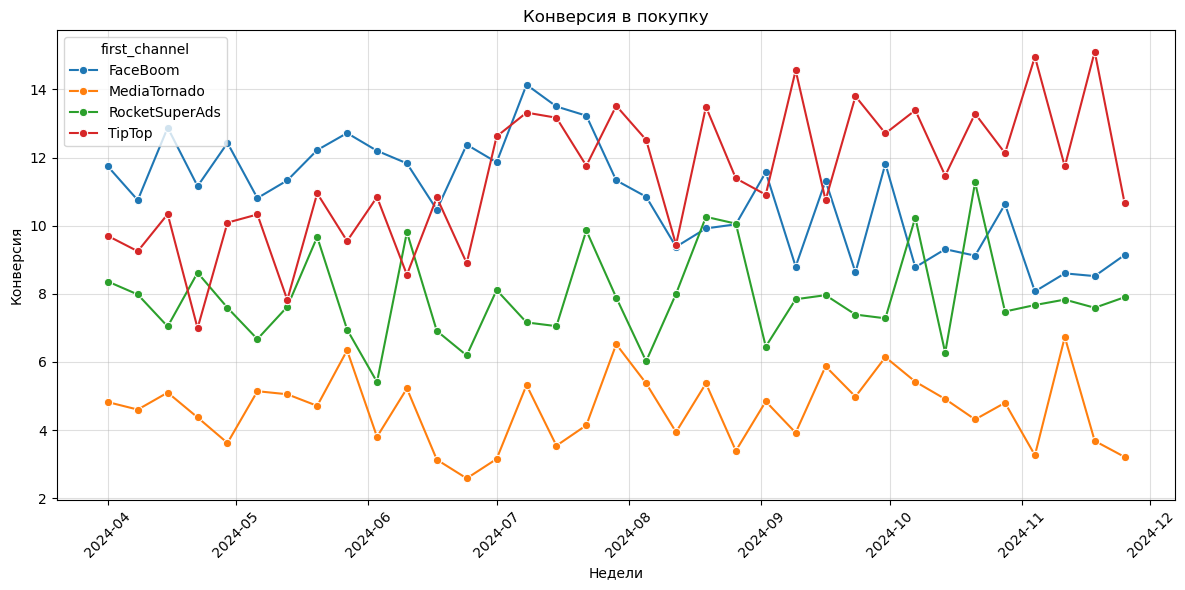

In [42]:
# Конверсия в покупку по недельным когортам и каналам

# Добавляем информацию о покупках
user_purchases = orders_df.groupby('user_id').agg({
    'event_dt': 'min',
    'revenue': 'sum'
}).reset_index()

user_purchases = user_purchases.rename(columns={
    'event_dt': 'first_purchase_dt',
    'revenue': 'total_revenue'
})

# Объединяем с профилями
weekly_conversion = pd.merge(
    profiles,
    user_purchases[['user_id', 'first_purchase_dt', 'total_revenue']],
    on='user_id',
    how='left'
)

# Округлим дату до начала недели
weekly_conversion['first_week'] = weekly_conversion['first_dt'].dt.to_period('W').dt.to_timestamp()

# Добавляем флаг о совершении покупки
weekly_conversion['has_purchased'] = weekly_conversion['total_revenue'].notna()
weekly_conversion['total_revenue'] = weekly_conversion['total_revenue'].fillna(0)

# Рассчитываем конверсию за 28 дней по недельным когортам
weekly_conversion_grouped = weekly_conversion.groupby(['first_week', 'first_channel']).agg({
    'user_id': 'count',
    'has_purchased': 'sum'
}).reset_index()

weekly_conversion_grouped = weekly_conversion_grouped.rename(columns={
    'user_id': 'cohort_size',
    'has_purchased': 'payers_count'
})

weekly_conversion_grouped['conversion_rate'] = (weekly_conversion_grouped['payers_count'] / weekly_conversion_grouped['cohort_size'] * 100).round(2)

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график с разделением по каналам
sns.lineplot(
    data=weekly_conversion_grouped,
    x='first_week',
    y='conversion_rate',
    hue='first_channel',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Недели')
plt.ylabel('Конверсия')

# Добавляем заголовок
plt.title('Конверсия в покупку')

plt.tight_layout()
plt.show()

График показывает конверсию в покупку по каналам.

- TipTop — лидер по конверсии, часто выше 12%, с пиковыми значениями до 15%.
- FaceBoom — второй по эффективности, колеблется вокруг 10–13%, но с ростом к концу года.
- RocketSuperAds — умеренная конверсия (~7–10%), с заметными скачками.
- MediaTornado — самый низкий уровень конверсии (3–6%), нестабильный.

Вывод: TipTop — самый конверсионный канал, FaceBoom — стабильно хороший, остальные — слабее и менее предсказуемы.

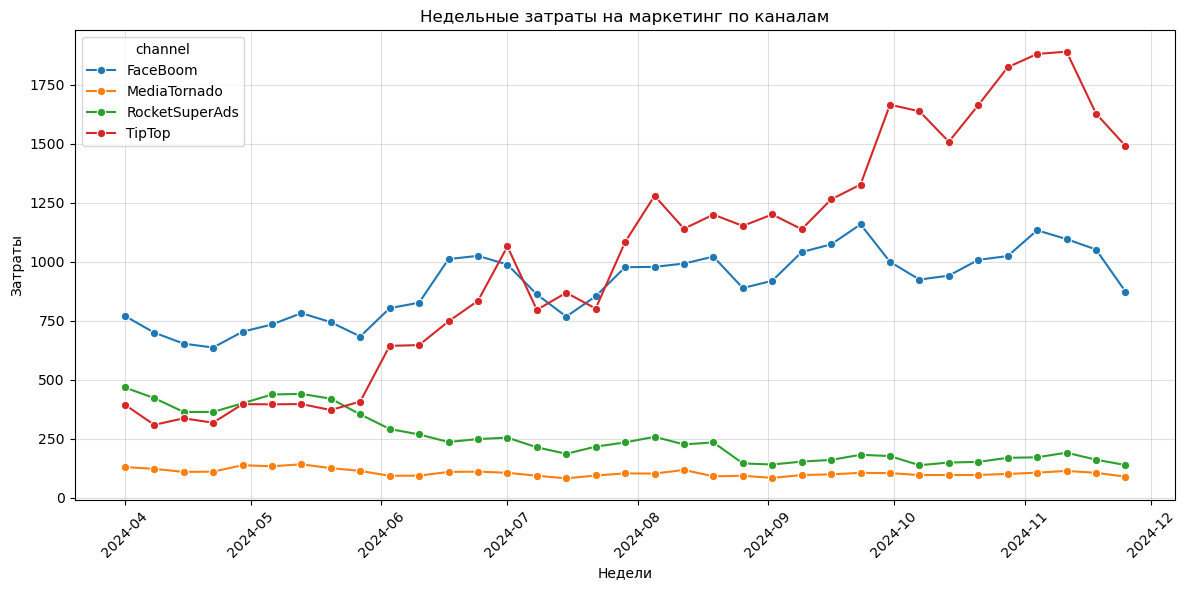

In [44]:
costs_weekly = costs_df.copy()

costs_weekly['first_week'] = costs_weekly['dt'].dt.to_period('W').dt.to_timestamp()

# Группируем данные по когорте (месяц первой активности) и каналу — рассчитываем средний CAC для каждой группы
costs_weekly_grouped = costs_weekly.groupby(['first_week', 'channel'], as_index=False).agg({
    'costs': 'sum'
})

# Конвертируем first_activity_week в timestamp для корректной работы с осью времени
costs_weekly_grouped['first_week'] = pd.to_datetime(costs_weekly_grouped['first_week'])

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график с разделением по каналам
sns.lineplot(
    data=costs_weekly_grouped,
    x='first_week',
    y='costs',
    hue='channel',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Недели')
plt.ylabel('Затраты')

# Добавляем заголовок
plt.title('Недельные затраты на маркетинг по каналам')

plt.tight_layout()
plt.show()

График показывает недельные маркетинговые затраты по каналам.

- TipTop — самые высокие и растущие затраты, пик — свыше 1750, затем снижение.
- FaceBoom — стабильные средние затраты (~700–1100), рост к осени, спад в декабре.
- RocketSuperAds и MediaTornado — низкие и почти не меняющиеся затраты (~100–300).

Вывод: Основной бюджет уходит на TipTop — канал с высокой конверсией и удержанием. FaceBoom — вторая по затратам, остальные — минимальные инвестиции.

,first_week,first_channel,total_users,avg_cac
0,2024-04-01,FaceBoom,809,0.951639
1,2024-04-01,MediaTornado,519,0.249168
2,2024-04-01,RocketSuperAds,538,0.867379
3,2024-04-01,TipTop,505,0.780177
4,2024-04-08,FaceBoom,735,0.950847


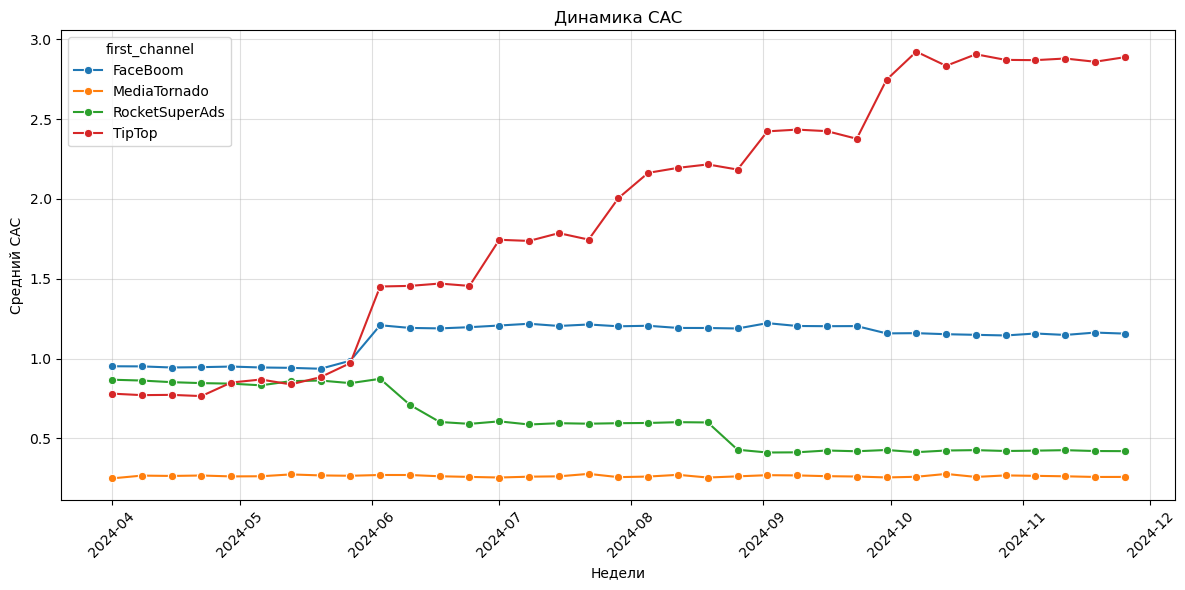

In [46]:
# Группируем данные по недели, считаем средний САС
cac_df = profiles.copy()

# Выделяем первую неделю привлечения
cac_df['first_week'] = cac_df['first_dt'].dt.to_period('W').dt.to_timestamp()

# Группируем данные по месяцу, считаем средний САС
cac = cac_df.groupby(['first_week', 'first_channel']).agg(
total_users = ('user_id','nunique'),
avg_cac = ('CAC','mean'),
).reset_index()

display(cac.head())

# Конвертируем first_month в timestamp для корректной работы с осью времени
cac['first_week'] = pd.to_datetime(cac['first_week'])

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график
sns.lineplot(
    data=cac,
    x='first_week',
    y='avg_cac',
    hue='first_channel',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Недели')
plt.ylabel('Средний CAC')

# Добавляем заголовок
plt.title('Динамика CAC')

plt.tight_layout()
plt.show()

График показывает динамику среднего CAC (стоимости привлечения одного пользователя) по каналам.

- ipTop — растёт с ~0.8 до ~2.9 — самый дорогой канал к концу периода, несмотря на высокую конверсию.
- FaceBoom — стабильно ~1.1–1.3 — умеренная стоимость привлечения.
- RocketSuperAds и MediaTornado — самые дешёвые (~0.3–0.6), но с низкой конверсией и удержанием.

Вывод: TipTop — эффективен, но дорожает; FaceBoom — баланс цены и качества; остальные — дешёвые, но малоэффективные.

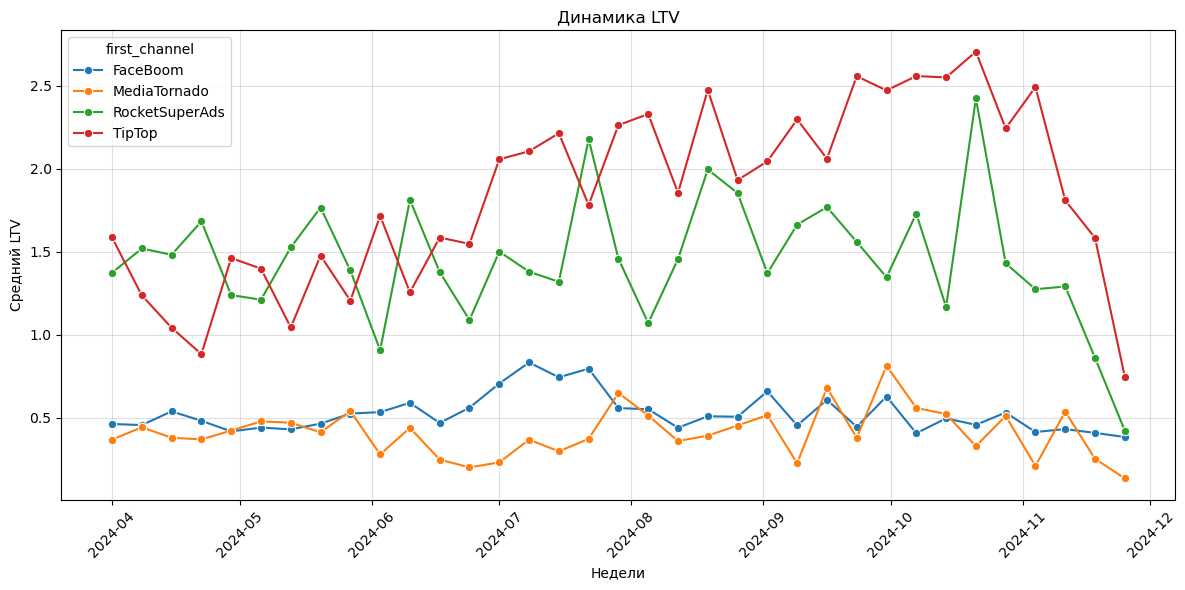

In [48]:
# Создаем когорты по неделям привлечения
profiles['first_week'] = profiles['first_dt'].dt.to_period('W').dt.to_timestamp()

# Фильтруем данные о покупках за первые 28 дней
orders_28d = orders_df[orders_df['lifetime'] <= 28].copy()

# Рассчитываем LTV за 28 дней для каждого пользователя
ltv = orders_28d.groupby('user_id')['revenue'].sum().reset_index()
ltv = ltv.rename(columns={'revenue': 'LTV'})

# Добавляем LTV к профилям
ltv = pd.merge(
    profiles,
    ltv[['user_id', 'LTV']],
    on='user_id',
    how='left'
)

ltv['LTV'] = ltv['LTV'].fillna(0)

# Рассчитываем метрики по когортам (неделям привлечения)
ltv = ltv.groupby(['first_week', 'first_channel']).agg({
    'user_id': 'count',
    'CAC': 'mean',
    'LTV': 'mean'
}).reset_index()

ltv = ltv.rename(columns={
    'user_id': 'cohort_size',
})

# Рассчитываем ROI за 28 дней
ltv['ROI'] = (ltv['LTV'] - ltv['CAC']) / ltv['CAC'] * 100
ltv['ROI'] = ltv['ROI'].replace([np.inf, -np.inf], 0)

# Конвертируем first_month в timestamp для корректной работы с осью времени
ltv['first_week'] = pd.to_datetime(ltv['first_week'])

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график
sns.lineplot(
    data=ltv,
    x='first_week',
    y='LTV',
    hue='first_channel',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Недели')
plt.ylabel('Средний LTV')

# Добавляем заголовок
plt.title('Динамика LTV')

plt.tight_layout()
plt.show()

График показывает динамику среднего LTV (жизненной ценности пользователя) по каналам.

- TipTop — лидер по LTV, растёт до 2.7–2.8, затем падает в ноябре–декабре — возможно, из-за снижения удержания.
- RocketSuperAds — второй по LTV (~1.3–2.2), но с высокой волатильностью.
- FaceBoom и MediaTornado — низкий LTV (~0.3–0.7), стабильно слабые показатели.

Вывод: TipTop приносит наибольшую долгосрочную ценность, несмотря на рост CAC и падение в конце. Остальные каналы — низкая отдача.

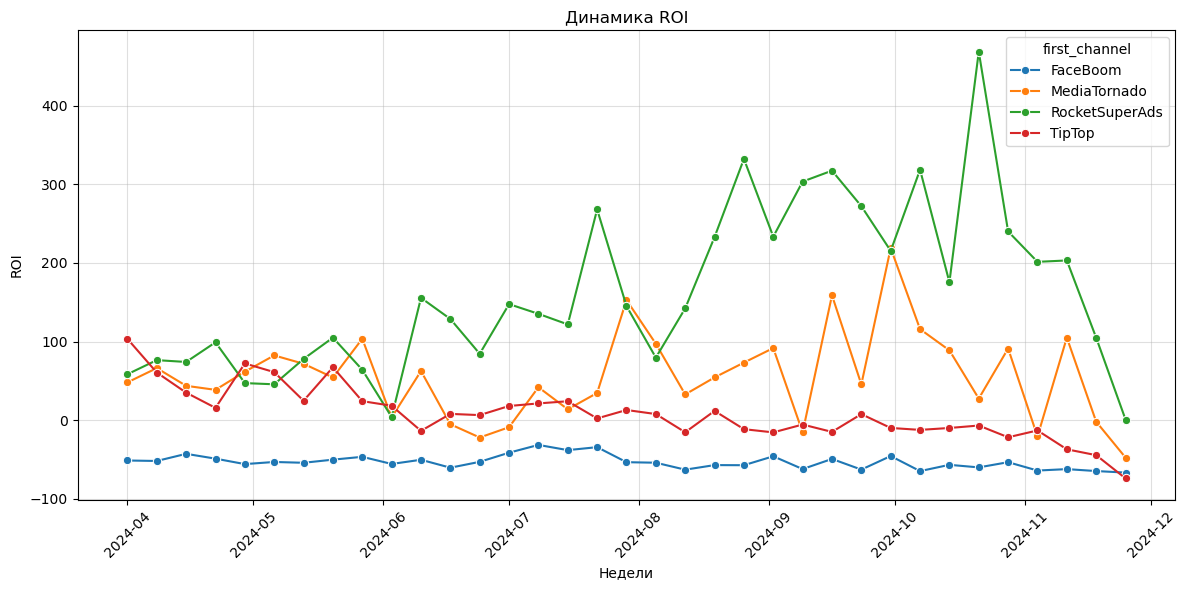

,first_week,first_channel,cohort_size,CAC,LTV,ROI
0,2024-04-01,FaceBoom,809,0.951639,0.462769,-51.371383
1,2024-04-01,MediaTornado,519,0.249168,0.368844,48.030068
2,2024-04-01,RocketSuperAds,538,0.867379,1.374126,58.422801
3,2024-04-01,TipTop,505,0.780177,1.586891,103.401421
4,2024-04-08,FaceBoom,735,0.950847,0.456544,-51.985536


In [50]:
# Конвертируем first_month в timestamp для корректной работы с осью времени
ltv['first_week'] = pd.to_datetime(ltv['first_week'])

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график
sns.lineplot(
    data=ltv,
    x='first_week',
    y='ROI',
    hue='first_channel',
    errorbar=('ci', False),
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Недели')
plt.ylabel('ROI')

# Добавляем заголовок
plt.title('Динамика ROI')

plt.tight_layout()
plt.show()

display(ltv.head())

График показывает динамику ROI (рентабельность инвестиций) по каналам.

- RocketSuperAds — лидер по ROI, пик — свыше 400%, но с резкими колебаниями и падением к концу.
- MediaTornado — умеренный ROI (~50–150%), нестабильный, с всплесками.
- TipTop — низкий или отрицательный ROI, несмотря на высокий LTV — из-за роста CAC.
- FaceBoom — почти всегда отрицательный ROI — трафик дешёвый, но слабая конверсия и удержание.

Вывод: RocketSuperAds — самый рентабельный, но непредсказуемый. TipTop — дорогой, но приносит ценность; FaceBoom — убыточный.

- **TipTop** — привлекает много пользователей, показывает высокую конверсию и LTV (до 2.8), но к концу года резко вырос CAC (до ~2.9) и упало удержание — ROI стал отрицательным. Не вышел на окупаемость из-за роста стоимости привлечения и потери лояльности. Возможно, канал перешёл на менее целевой трафик или произошли изменения в продукте/предложении.

- **FaceBoom** — стабильно привлекает много пользователей и имеет хорошую конверсию, но удержание крайне низкое (~ 2–3%), а LTV — минимальный (~ 0.5). Не вышел на окупаемость — несмотря на умеренный CAC, пользователи не приносят долгосрочной ценности. Вероятно, трафик «холодный» или не соответствует ожиданиям продукта.

- **MediaTornado** — дешёвый канал (CAC ~0.3), но низкая конверсия и LTV ограничивают отдачу. ROI иногда положительный, но нестабильный. Не вышел на устойчивую окупаемость — подходит для тестов, но не для масштабирования. Проблема в качестве трафика или слабой воронке продаж.

- **RocketSuperAds** — единственный канал, который устойчиво вышел на окупаемость: низкий CAC, хороший LTV и высокий ROI (до 400%). Несмотря на волатильность, он эффективен. Ограничение — малый объём трафика. Если стабилизировать, может стать основным источником прибыли.

## Анализ периода окупаемости маркетинговых вложений

In [54]:
orders = orders_df
costs = costs_df

In [55]:
# определяем неделю покупки с момента привлечения пользователя (лайфтайм в неделях)

orders['order_week'] = pd.to_datetime(orders.event_dt).dt.to_period('W').dt.to_timestamp()


In [56]:
orders['first_week'] = orders['first_dt'].dt.to_period('W').dt.to_timestamp()

In [57]:
# определяем порядковый номер недели для датафрейма с маркетинговыми расходами по каналам
costs_df['week'] = pd.to_datetime(costs_df['dt']).dt.to_period('W').dt.to_timestamp()

# определяем неделю покупки с момента привлечения пользователя (лайфтайм в неделях)

orders['week_since_install'] = (orders['order_week'] - orders['first_week']).dt.days / 7


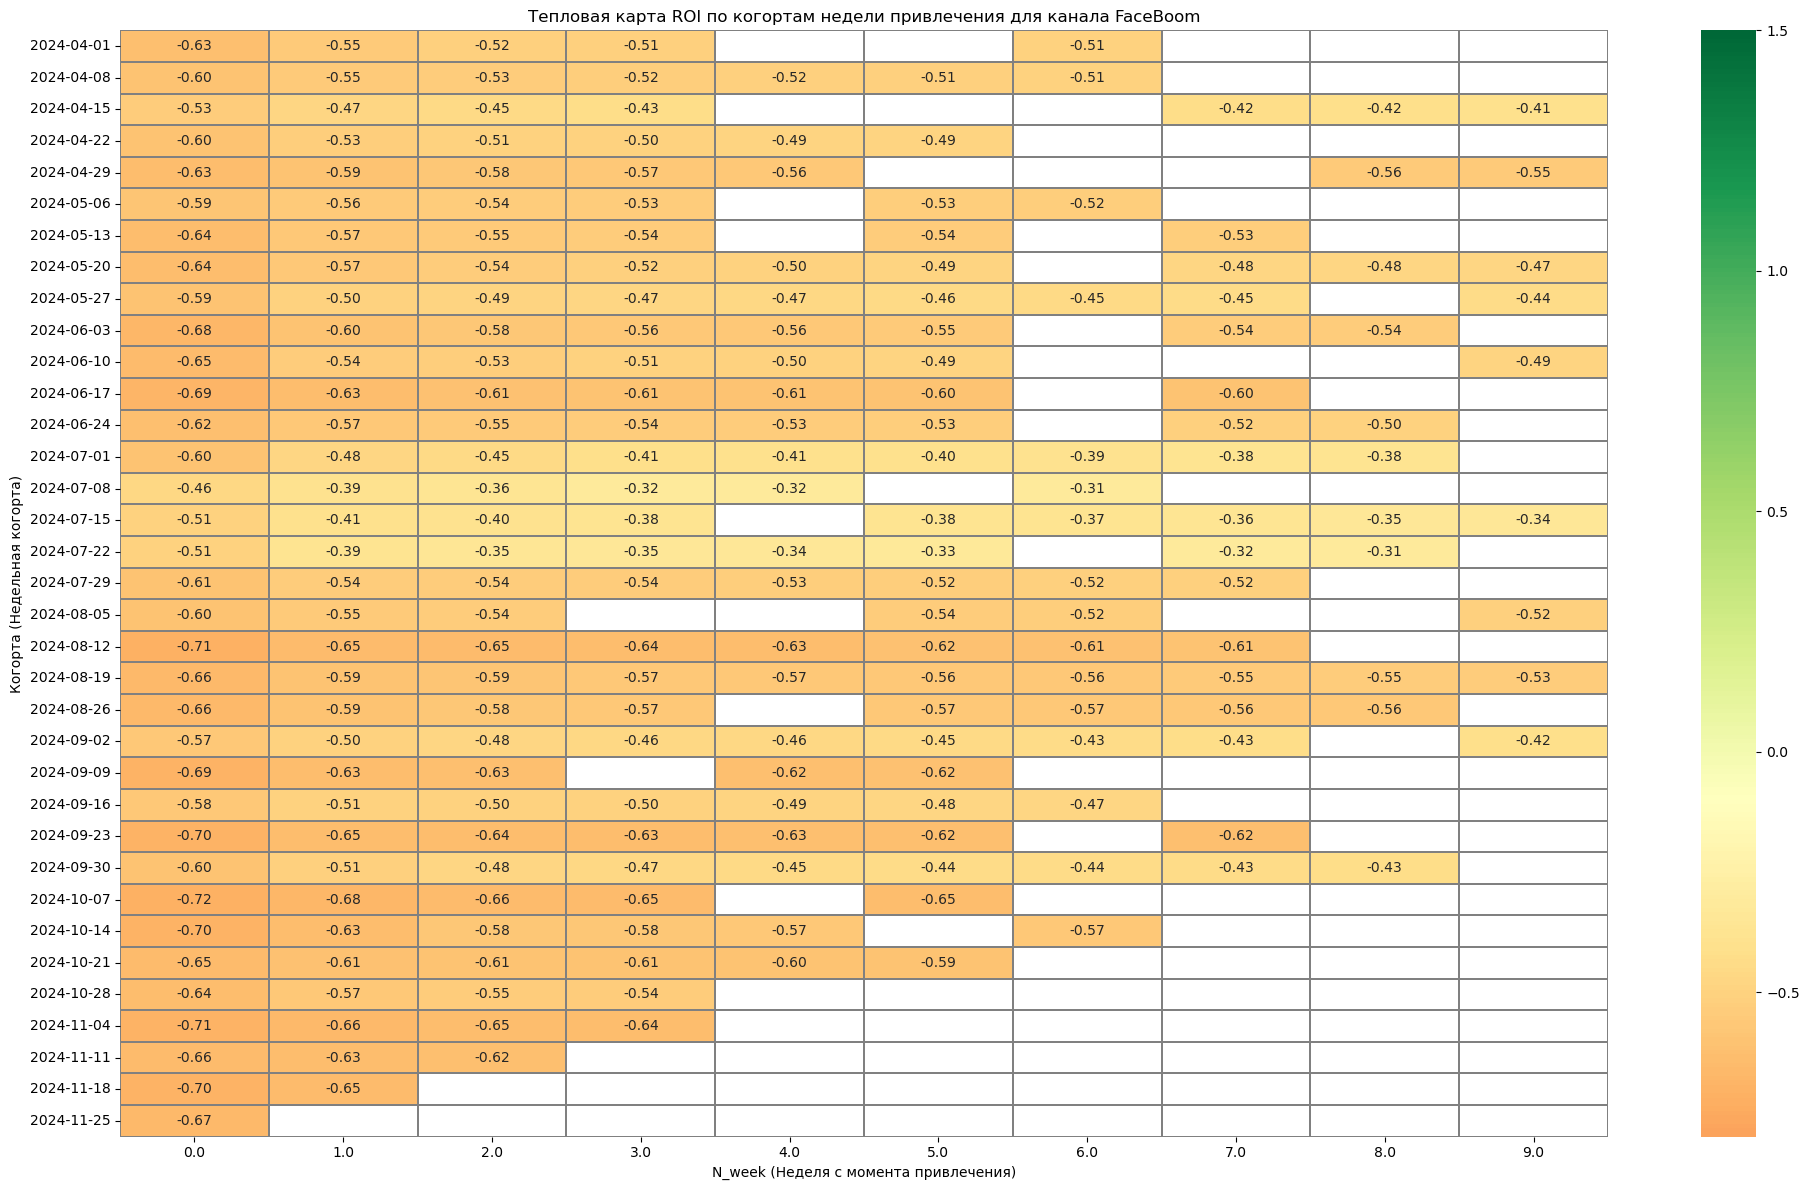

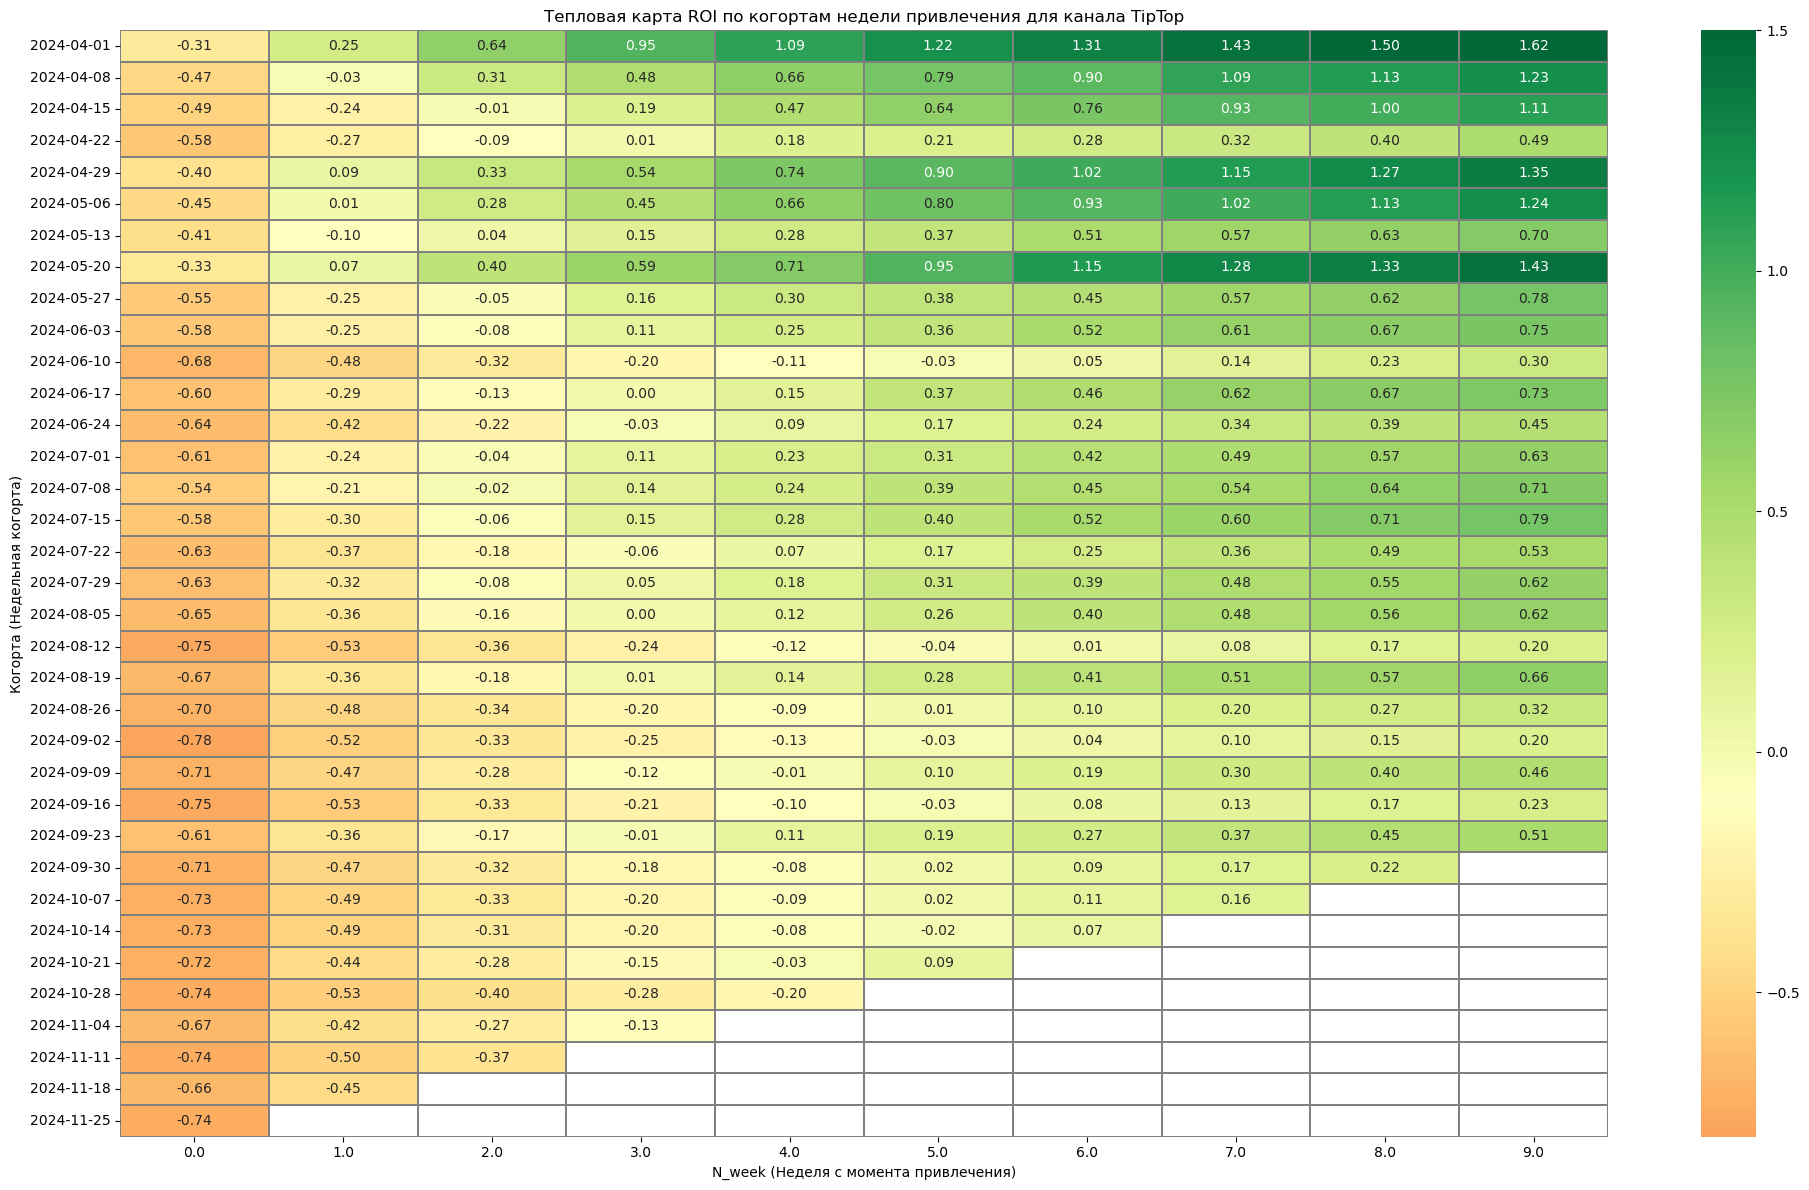

In [58]:
bad_channels = ['FaceBoom', 'TipTop']

for channel in bad_channels:
    # фильруем заказы по каналу привлечения
    chan_orders = orders[orders['first_channel'] == channel].copy()

    # определяем объем когорты (к-во уникальных польз.) с группировкой по неделе привлечения
    cohort_sizes = chan_orders.groupby('first_week').user_id.nunique().reset_index().rename(columns={'user_id': 'users_in_cohort'})
    # display(cohort_sizes.head())

    # вычисляем выручку когорты недели привлечения
    cohort_revenue = chan_orders.groupby(['first_week', 'week_since_install']).revenue.sum().reset_index()
    # display(cohort_revenue.head())

    # определяем маркетинговые расходы на недельную когорту
    chan_costs = costs[costs['channel'] == channel].copy()
    chan_weekly_costs = chan_costs.groupby('week').costs.sum().reset_index().rename(columns={'week': 'first_week'})

    # display(chan_weekly_costs.head())

    # объединяем данные о понедельных доходах с объемами когорт
    cohort_data = cohort_revenue.merge(cohort_sizes, on='first_week', how='left')

    # добавляем данные о расходах на привелечение когорты
    cohort_data = cohort_data.merge(chan_weekly_costs, on='first_week', how='right')
    # cohort_data['costs'] = cohort_data.costs.fillna(0)

    # вычисляем накопление дохода каждой когорты по ходу недельного лайфтайма week_since_install
    # предварительно проверяем хронологическую сортировку
    cohort_data.sort_values(['first_week', 'week_since_install'], inplace=True)
    cohort_data['cum_revenue'] = cohort_data.groupby('first_week').revenue.cumsum()

    # вычисляем CAC - общий для когорты
    cohort_data['CAC'] = cohort_data.costs / cohort_data.users_in_cohort

    # вычисляем LTV - меняется с лайфтаймом
    cohort_data['LTV'] = cohort_data.cum_revenue / cohort_data.users_in_cohort

    # вычисляем ROI - тоже будет динамическим и показывать окупаемость на момент лайфтайма
    cohort_data['ROI'] = (cohort_data['LTV'] - cohort_data['CAC']) / cohort_data['CAC']
    # cohort_data['ROI'] = (cohort_data.cum_revenue - cohort_data.costs) / cohort_data.costs

    # приводим индексы к форматк даты
    cohort_data['first_week'] = cohort_data.first_week.dt.date

    prep = cohort_data[(cohort_data.week_since_install >= 0) & (cohort_data.week_since_install < 10)].copy()

    heatmap_df = prep.pivot(
        index='first_week',
        columns='week_since_install',
        values='ROI'
    )
    # display(cohort_data)

    cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
    
    plt.figure(figsize=(20, 12))
    sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap='RdYlGn', center=-0.1, vmin=-0.8, vmax=1.5, linewidths=0.1, linecolor='gray')
    plt.title(f'Тепловая карта ROI по когортам недели привлечения для канала {channel}')
    plt.xlabel('N_week (Неделя с момента привлечения)')
    plt.ylabel('Когорта (Недельная когорта)')
    plt.tight_layout()
    plt.show()



- **FaceBoom** не выходит на окупаемость даже спустя 9 недель после привлечения пользователей: на всей тепловой карте ROI остаётся отрицательным или близким к нулю, независимо от даты формирования когорты. Это говорит о том, что вложения в этот канал не окупаются в принципе — вероятно, из-за крайне низкого удержания и малого LTV, несмотря на высокий объём трафика и приемлемую конверсию. Скорее всего, канал привлекает нецелевую или «холодную» аудиторию, которая совершает разовую покупку, но не возвращается, и её пожизненная ценность не покрывает стоимость привлечения.

- **TipTop**, напротив, ранее показывал отличную окупаемость: когорты, привлечённые до июля 2024 года, выходили в плюс уже к 3–4 неделе и достигали ROI выше 1.0 к 6–8 неделе. Однако начиная с августа наблюдается резкий перелом — новые когорты не окупаются даже за 9 недель, демонстрируя устойчиво отрицательный ROI. Это совпадает с ростом CAC и падением 14-дневного удержания, зафиксированным ранее, и указывает на то, что с лета изменилась либо стратегия таргетинга, либо качество трафика, либо пользовательский опыт в продукте. Без вмешательства ситуация с TipTop будет усугубляться, несмотря на его историческую эффективность.

Таким образом, из двух проанализированных каналов только ранние когорты TipTop окупались — и то в течение 3–4 недель, — а FaceBoom не окупается вовсе. Это подтверждает необходимость перераспределения бюджета в пользу каналов с доказанной рентабельностью, таких как RocketSuperAds, и глубокого аудита изменений в TipTop с августа 2024 года.

## Выводы и рекомендации

Общий анализ показывает, что аудитория продукта сильно зависит от источника привлечения: одни каналы приносят лояльных пользователей, другие — разовый трафик без ценности. При этом маркетинговый бюджет распределён неоптимально: основные средства уходят в каналы с низкой или отрицательной рентабельностью.

- **TipTop** ранее был сильным каналом — с высокой конверсией, удержанием и LTV, окупаясь за 3–4 недели. Однако с августа 2024 года его эффективность резко упала: CAC вырос, удержание обвалилось, и ROI стал отрицательным даже за 9 недель. Это указывает на проблему в таргетинге, качестве трафика или продукте, которую нужно срочно выявить и устранить.

- **FaceBoom** привлекает много пользователей и имеет хорошую конверсию, но почти не удерживает их (всего 2–3% на 14-й день), из-за чего LTV остаётся низким, а ROI — отрицательным даже спустя 9 недель. Канал не окупается в принципе, вероятно, из-за несоответствия между привлекаемой аудиторией и продуктом.

- **RocketSuperAds**, напротив, при минимальных затратах демонстрирует высокий ROI (до 400%) и стабильный LTV, окупаясь быстро и надёжно. Это единственный по-настоящему прибыльный канал, который стоит масштабировать.

- **MediaTornado** работает на фоне: дёшев, но малоэффективен — низкая конверсия и LTV ограничивают его вклад.

Рекомендуется немедленно сократить бюджет на FaceBoom, перераспределить средства в RocketSuperAds и запустить аудит TipTop, чтобы вернуть ему окупаемость. Также важно принимать решения на основе когортного ROI за 6–9 недель, а не по первичной конверсии, и сосредоточиться на качестве трафика, а не на его объёме. Это позволит повысить эффективность рекламных вложений и обеспечить устойчивый рост.